# AI-Based Cyber Threat Detection Framework
### Step 1: Import Libraries and Load Network Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Libraries successfully imported!")

Libraries successfully imported!


### Step 2: Simulate/Load Network Traffic Dataset
We generate dummy data mapping standard network features (e.g., packet size, duration, rate) to demonstrate the framework pipeline.

In [4]:
# Simulate 1000 network connections
np.random.seed(42)
n_samples = 1000

data = {
    'duration': np.random.exponential(scale=2.0, size=n_samples),
    'packet_count': np.random.randint(1, 500, size=n_samples),
    'byte_count': np.random.randint(64, 150000, size=n_samples),
    'rate': np.random.uniform(0.1, 1000.0, size=n_samples),
    'label': np.random.choice(['Normal', 'DDoS', 'Brute Force', 'Infiltration'], p=[0.7, 0.15, 0.1, 0.05], size=n_samples)
}

df = pd.DataFrame(data)
print(df['label'].value_counts())
df.head()

label
Normal          712
DDoS            137
Brute Force     112
Infiltration     39
Name: count, dtype: int64


,duration,packet_count,byte_count,rate,label
0,0.938536,303,78778,841.739189,Normal
1,6.020243,12,24660,580.263497,Normal
2,2.633491,318,64170,559.732476,Normal
3,1.825885,80,59246,105.348659,Normal
4,0.339250,216,87227,167.442997,Normal


### Step 3: Data Preprocessing and Feature Encoding

In [5]:
# Encode the target labels
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df['label'])

# Split into features (X) and target (y)
X = df.drop(['label', 'label_encoded'], axis=1)
y = df['label_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data processing complete. Train shape:", X_train_scaled.shape)

Data processing complete. Train shape: (800, 4)


### Step 4: Model Training (Supervised Classifier)

In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Model Training Finished!")

Model Training Finished!


### Step 5: Evaluate Framework Results

Overall Model Accuracy: 72.50%

Classification Report:
              precision    recall  f1-score   support

 Brute Force       0.00      0.00      0.00        17
        DDoS       0.00      0.00      0.00        20
Infiltration       0.00      0.00      0.00        13
      Normal       0.75      0.97      0.84       150

    accuracy                           0.72       200
   macro avg       0.19      0.24      0.21       200
weighted avg       0.56      0.72      0.63       200



C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


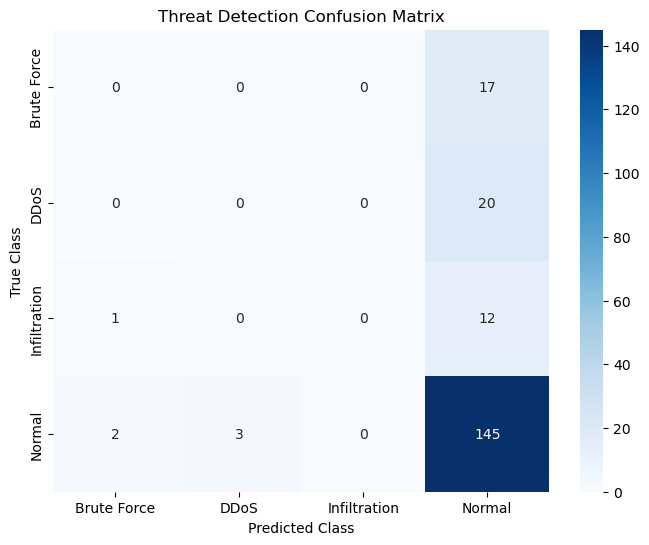

In [7]:
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Threat Detection Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()